# Squat Form Detection — Random Forest v2
**IMU-only · 4-class severity · 8 subjects · LOSO validation**

Random Forest with hand-crafted features. MoCap toes-shank angle used as ground truth labels. Model trains and infers on IMU only.

## Cell 0 — Install

## Cell 1 — Imports & Config

In [2]:
import os, warnings, json as json_module
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────
BASE      = r'C:\Users\javie\OneDrive - The University of Texas at Austin\Documents\UT - Spring 2026\Human Signals\Final Project'
BASE_FILT = BASE + r'\Filtered_data'

# ── Rates & window config ──────────────────────────────────
KINE_HZ   = 100
TARGET_HZ = 29
WIN_SEC   = 2.0
OVERLAP   = 0.75
WIN_LEN   = int(WIN_SEC * TARGET_HZ)   # 58 frames
STEP      = int(WIN_LEN * (1 - OVERLAP))

# ── IMU channels (model input only — no kinematics) ────────
imu_cols = ['ax','ay','az','gx','gy','gz','pitch','roll','yaw']

# ── Label map (right knee toes-shank angle) ────────────────
SHEET_LABEL_R = {
    'R < 7'        : 0,
    '10 > R => 7'  : 1,
    '15 > R => 10' : 2,
    'R => 15'      : 3,
}
LABEL_NAMES = ['correct (<7deg)', 'mild (7-10deg)', 'moderate (10-15deg)', 'severe (>15deg)']
N_CLASSES   = 4

print(f'Window: {WIN_LEN} frames ({WIN_SEC}s @ {TARGET_HZ}Hz)  Step: {STEP} frames')
print(f'IMU channels: {imu_cols}')
print(f'Labels: {LABEL_NAMES}')

Window: 58 frames (2.0s @ 29Hz)  Step: 14 frames
IMU channels: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'pitch', 'roll', 'yaw']
Labels: ['correct (<7deg)', 'mild (7-10deg)', 'moderate (10-15deg)', 'severe (>15deg)']


## Cell 2 — Data Loading Functions

In [3]:
def load_kine_from_xlsx(xlsx_path):
    """Load frame sequence and time axis from main sheet of bin xlsx."""
    xl   = pd.read_excel(xlsx_path, sheet_name=0)
    data = xl.iloc[3:].copy()
    data.columns = ['frame', 'L_Knee', 'R_Knee']
    data['frame']  = pd.to_numeric(data['frame'],  errors='coerce')
    data['R_Knee'] = pd.to_numeric(data['R_Knee'], errors='coerce')
    data['L_Knee'] = pd.to_numeric(data['L_Knee'], errors='coerce')
    data = data.dropna(subset=['frame']).reset_index(drop=True)
    data['frame']  = data['frame'].astype(int)
    data = data.sort_values('frame').reset_index(drop=True)
    data['time_s'] = (data['frame'] - 1) / KINE_HZ
    return data

def build_frame_labels(xlsx_path):
    """Build {frame: severity_label} dict from bin sheets (right knee only)."""
    xl = pd.read_excel(xlsx_path, sheet_name=None)
    frame_labels = {}
    for sheet_name, label in SHEET_LABEL_R.items():
        sheet_df = xl[sheet_name]
        data = sheet_df.iloc[3:].copy()
        data.columns = ['frame', 'L_Knee', 'R_Knee']
        data['frame'] = pd.to_numeric(data['frame'], errors='coerce')
        frames = data.dropna(subset=['frame'])['frame'].astype(int).values
        for f in frames:
            frame_labels[f] = label
    return frame_labels

def load_watch_imu(fpath):
    """Load SensorLog CSV and return clean IMU DataFrame."""
    df = pd.read_csv(fpath)
    rename = {
        'loggingTime(txt)'               : 'timestamp',
        'motionUserAccelerationX(G)'      : 'ax',
        'motionUserAccelerationY(G)'      : 'ay',
        'motionUserAccelerationZ(G)'      : 'az',
        'motionRotationRateX(rad/s)'      : 'gx',
        'motionRotationRateY(rad/s)'      : 'gy',
        'motionRotationRateZ(rad/s)'      : 'gz',
        'motionPitch(rad)'                : 'pitch',
        'motionRoll(rad)'                 : 'roll',
        'motionYaw(rad)'                  : 'yaw',
    }
    df = df.rename(columns=rename)
    if 'timestamp' in df.columns:
        df = df[df['timestamp'].astype(str).str.startswith('2026', na=False)].reset_index(drop=True)
    df['t']      = pd.to_datetime(df['timestamp'], format='mixed')
    df['time_s'] = (df['t'] - df['t'].iloc[0]).dt.total_seconds()
    for col in imu_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df[['time_s'] + imu_cols].dropna().reset_index(drop=True)

def resample_to_hz(df, time_col, value_cols, target_hz):
    """Resample DataFrame to target_hz using linear interpolation."""
    t_orig = df[time_col].values
    t_new  = np.arange(t_orig[0], t_orig[-1], 1.0 / target_hz)
    out = {'time_s': t_new}
    for col in value_cols:
        f = interp1d(t_orig, df[col].values, kind='linear', fill_value='extrapolate')
        out[col] = f(t_new)
    return pd.DataFrame(out)

print('Data loading functions ready.')

Data loading functions ready.


## Cell 3 — Build Windows (IMU-only, MoCap labels)

In [4]:
# ── Trial registry ─────────────────────────────────────────
# Format: (xlsx_path, imu_csv_path, trial_name, subject_id)
TRIAL_REGISTRY = [
    (BASE_FILT + r'\Good_1_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_38_29.csv',   'Good1', 'S01'),
    (BASE_FILT + r'\Good_2_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_39_59.csv',   'Good2', 'S02'),
    (BASE_FILT + r'\Good_3_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_41_36.csv',   'Good3', 'S03'),
    (BASE_FILT + r'\Bad_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_43_42_bad.csv', 'Bad1', 'S04'),
    (BASE_FILT + r'\Good_4_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_47_16.csv',   'Good4', 'S05'),
    (BASE_FILT + r'\Good_5_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_48_50.csv',   'Good5', 'S06'),
    (BASE_FILT + r'\Good_6_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_50_33.csv',   'Good6', 'S07'),
    (BASE_FILT + r'\Bad_2_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_57_30_bad2.csv', 'Bad2', 'S08'),
    # ── Pending: Good7 (MoCap on other computer) ──────────
    # (BASE_FILT + r'\Good_7_Data_ToesRef_filt.xlsx',
    #  BASE_FILT + r'\stream_Apple_Watch_260414_15_54_40.csv', 'Good7', 'S09'),
]

X_all, y_all, subj_all = [], [], []

for (xlsx_path, imu_path, trial_name, subj_id) in TRIAL_REGISTRY:
    frame_labels = build_frame_labels(xlsx_path)
    kine         = load_kine_from_xlsx(xlsx_path)
    kine['label']= kine['frame'].map(frame_labels).fillna(0).astype(int)
    imu          = load_watch_imu(imu_path)

    kine_rs = resample_to_hz(kine, 'time_s', ['R_Knee', 'L_Knee'], TARGET_HZ)
    label_interp = interp1d(kine['time_s'].values, kine['label'].values,
                             kind='nearest', fill_value='extrapolate')
    kine_rs['label'] = label_interp(kine_rs['time_s'].values).astype(int).clip(0, 3)

    t_s   = max(kine_rs['time_s'].min(), imu['time_s'].min())
    t_e   = min(kine_rs['time_s'].max(), imu['time_s'].max())
    tgrid = kine_rs[(kine_rs['time_s']>=t_s)&(kine_rs['time_s']<=t_e)]['time_s'].values
    km    = kine_rs[(kine_rs['time_s']>=t_s)&(kine_rs['time_s']<=t_e)].reset_index(drop=True)

    for col in imu_cols:
        f_i = interp1d(imu['time_s'].values, imu[col].values,
                       kind='linear', fill_value='extrapolate')
        km[col] = f_i(tgrid)

    imu_arr   = km[imu_cols].values
    label_arr = km['label'].values

    windows, labels = [], []
    for i in range(0, len(imu_arr) - WIN_LEN, STEP):
        win       = imu_arr[i : i + WIN_LEN]
        win_label = int(label_arr[i : i + WIN_LEN].max())
        windows.append(win)
        labels.append(win_label)

    X_all.append(np.array(windows))
    y_all.append(np.array(labels))
    subj_all.extend([subj_id] * len(windows))

    dist = Counter(labels)
    print(f'{trial_name:6s} ({subj_id}) -> {len(windows):4d} windows | '
          f'0:{dist.get(0,0):4d}  1:{dist.get(1,0):3d}  '
          f'2:{dist.get(2,0):3d}  3:{dist.get(3,0):3d}')

X        = np.concatenate(X_all)
y        = np.concatenate(y_all)
subjects = np.array(subj_all)
N, T, C  = X.shape
print(f'\nTotal: {X.shape} | Label dist: {dict(sorted(Counter(y).items()))}')
print(f'Subjects: {sorted(np.unique(subjects))}')

# ── Normalize — fit on train split only ───────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X, y))

scaler  = StandardScaler()
X_train = scaler.fit_transform(
    X[train_idx].reshape(len(train_idx), T*C)).reshape(len(train_idx), T, C)
X_test  = scaler.transform(
    X[test_idx].reshape(len(test_idx), T*C)).reshape(len(test_idx), T, C)
y_train = y[train_idx]
y_test  = y[test_idx]
subj_train = subjects[train_idx]
N_CHANNELS = C

class_weights       = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict   = dict(enumerate(class_weights))

joblib.dump(scaler, 'scaler_imu_only.pkl')

# ── Export scaler params as JSON for Watch deployment ─────
scaler_params = {
    'mean'        : scaler.mean_.tolist(),
    'scale'       : scaler.scale_.tolist(),
    'feature_names': imu_cols,
    'win_len'     : WIN_LEN,
    'step'        : STEP,
    'target_hz'   : TARGET_HZ,
}
with open('scaler_params.json', 'w') as f:
    json_module.dump(scaler_params, f, indent=2)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
for lbl, name in enumerate(LABEL_NAMES):
    tr = np.sum(y_train==lbl); te = np.sum(y_test==lbl)
    print(f'  {lbl} {name:30s}: train={tr:4d}  test={te:3d}')
print(f'Class weights: {[round(float(w),2) for w in class_weights]}')
print('Scaler saved -> scaler_imu_only.pkl')
print('Scaler params saved -> scaler_params.json  (use this in Swift)')

Good1  (S01) ->   49 windows | 0:  17  1: 22  2:  0  3: 10
Good2  (S02) ->   70 windows | 0:  36  1: 13  2:  3  3: 18
Good3  (S03) ->   85 windows | 0:  26  1: 36  2: 12  3: 11
Bad1   (S04) ->   84 windows | 0:  38  1: 20  2:  9  3: 17
Good4  (S05) ->   75 windows | 0:  46  1: 11  2:  1  3: 17
Good5  (S06) ->   71 windows | 0:  44  1:  8  2:  0  3: 19
Good6  (S07) ->   52 windows | 0:   9  1:  8  2:  6  3: 29
Bad2   (S08) ->   70 windows | 0:  25  1: 16  2:  9  3: 20

Total: (556, 58, 9) | Label dist: {np.int64(0): 241, np.int64(1): 134, np.int64(2): 40, np.int64(3): 141}
Subjects: [np.str_('S01'), np.str_('S02'), np.str_('S03'), np.str_('S04'), np.str_('S05'), np.str_('S06'), np.str_('S07'), np.str_('S08')]
Train: 444  |  Test: 112
  0 correct (<7deg)               : train= 192  test= 49
  1 mild (7-10deg)                : train= 107  test= 27
  2 moderate (10-15deg)           : train=  32  test=  8
  3 severe (>15deg)               : train= 113  test= 28
Class weights: [0.58, 1.04, 3

## Cell 4 — Evaluate Helper

In [5]:
def evaluate(model_name, y_true, y_pred, save_prefix=''):
    present = sorted(np.unique(np.concatenate([y_true, y_pred])))
    names   = [LABEL_NAMES[i] for i in present]
    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred, labels=present,
                                  target_names=names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=present)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, linewidths=0.5)
    plt.title(f'{model_name} -- Confusion Matrix', fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    fname = f'cm_{save_prefix}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight'); plt.show()
    print(f'Saved -> {fname}')
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'Macro F1: {f1:.3f}')
    return f1

print('evaluate() ready.')

evaluate() ready.


## Cell 5 — Random Forest Model & Grid Search

Feature vector size: 60
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 1000}
Best CV F1:  0.575

  Random Forest
                     precision    recall  f1-score   support

    correct (<7deg)       0.68      0.82      0.74        49
     mild (7-10deg)       0.50      0.33      0.40        27
moderate (10-15deg)       0.50      0.25      0.33         8
    severe (>15deg)       0.77      0.86      0.81        28

           accuracy                           0.67       112
          macro avg       0.61      0.56      0.57       112
       weighted avg       0.65      0.67      0.65       112



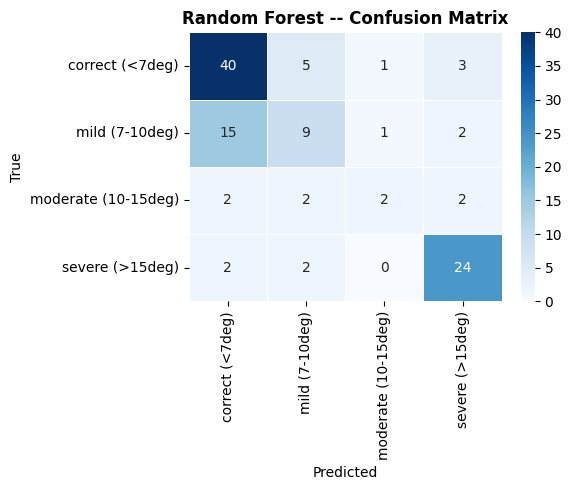

Saved -> cm_rf.png
Macro F1: 0.572
Saved -> rf_imu_only.pkl


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# ── Feature extraction ─────────────────────────────────────
def extract_features(window):
    """Hand-crafted IMU features for above-knee valgus detection. Shape (WIN_LEN, 9)."""
    feats = []
    for i in range(window.shape[1]):
        col = window[:, i]
        feats += [col.mean(), col.std(), col.max()-col.min(),
                  np.sum(col**2), np.abs(col).mean(),
                  np.percentile(col,90)-np.percentile(col,10)]
    gx   = window[:, 3]
    roll = window[:, 7]
    az   = window[:, 2]
    feats.append(np.ptp(gx))
    feats.append(np.ptp(roll))
    corr = np.corrcoef(gx, roll)[0,1] if gx.std()>0 and roll.std()>0 else 0
    feats.append(corr)
    az_e = np.sum(az**2) + 1e-8
    feats.append(np.sum(gx**2)   / az_e)
    feats.append(np.sum(roll**2) / az_e)
    feats.append(float(np.sum(np.diff(np.sign(gx)) != 0)))
    return np.array(feats, dtype=np.float32)

X_tr_f = np.array([extract_features(w) for w in X_train])
X_te_f = np.array([extract_features(w) for w in X_test])
print(f'Feature vector size: {X_tr_f.shape[1]}')

# ── Grid search ────────────────────────────────────────────
param_grid = {
    'n_estimators'    : [100, 200, 500],
    'max_depth'       : [5, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'class_weight'    : ['balanced', 'balanced_subsample'],
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='f1_macro', n_jobs=-1, verbose=1
)
grid.fit(X_tr_f, y_train)
print(f'\nBest params: {grid.best_params_}')
print(f'Best CV F1:  {grid.best_score_:.3f}')

rf = grid.best_estimator_
joblib.dump(rf, 'rf_imu_only.pkl')
y_pred_rf = rf.predict(X_te_f)
evaluate('Random Forest', y_test, y_pred_rf, save_prefix='rf')
print('Saved -> rf_imu_only.pkl')

## Cell 6 — Feature Importance (Gini)

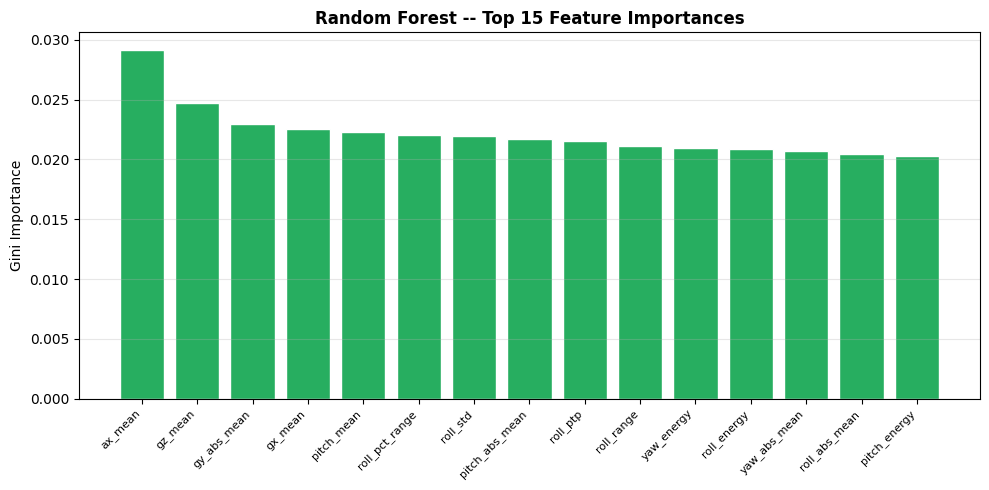

Top 5 features:
  ax_mean                            : 0.0292
  gz_mean                            : 0.0247
  gy_abs_mean                        : 0.0229
  gx_mean                            : 0.0225
  pitch_mean                         : 0.0223


In [8]:
# ── Gini feature importance ───────────────────────────────
feat_names = []
for ch in imu_cols:
    feat_names += [f'{ch}_mean', f'{ch}_std', f'{ch}_range',
                   f'{ch}_energy', f'{ch}_abs_mean', f'{ch}_pct_range']
feat_names += ['gx_ptp','roll_ptp','gx_roll_corr',
               'gx_az_energy_ratio','roll_az_energy_ratio','gx_zero_cross']

importances = rf.feature_importances_
top_idx     = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[top_idx], color='#27AE60', edgecolor='white')
plt.xticks(range(15), [feat_names[i] for i in top_idx],
           rotation=45, ha='right', fontsize=8)
plt.ylabel('Gini Importance')
plt.title('Random Forest -- Top 15 Feature Importances', fontweight='bold')
plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=130); plt.show()
print('Top 5 features:')
for i in top_idx[:5]:
    print(f'  {feat_names[i]:<35s}: {importances[i]:.4f}')

## Cell 7 — LOSO & 5-Fold Cross-Validation

In [9]:
# ── LOSO Cross-Validation ──────────────────────────────────
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_val_score

logo = LeaveOneGroupOut()
loso_scores = []

print('LOSO Cross-Validation (8 subjects):')
print('-'*55)

for fold, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups=subjects)):
    subj_te = subjects[te_idx][0]

    sc_fold   = StandardScaler()
    X_tr_norm = sc_fold.fit_transform(
        X[tr_idx].reshape(len(tr_idx), T*C)).reshape(len(tr_idx), T, C)
    X_te_norm = sc_fold.transform(
        X[te_idx].reshape(len(te_idx), T*C)).reshape(len(te_idx), T, C)

    X_tr_feat = np.array([extract_features(w) for w in X_tr_norm])
    X_te_feat = np.array([extract_features(w) for w in X_te_norm])

    if len(np.unique(y[te_idx])) < 2:
        print(f'  Fold {fold+1} ({subj_te}): skipped -- only 1 class in test')
        continue

    rf_fold = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        min_samples_leaf=1, class_weight='balanced', random_state=42)
    rf_fold.fit(X_tr_feat, y[tr_idx])
    preds = rf_fold.predict(X_te_feat)
    f1    = f1_score(y[te_idx], preds, average='macro', zero_division=0)
    loso_scores.append(f1)
    print(f'  Fold {fold+1} (test={subj_te}): macro F1={f1:.3f} | '
          f'test dist={dict(sorted(Counter(y[te_idx]).items()))}')

print('-'*55)
print(f'LOSO Mean F1: {np.mean(loso_scores):.3f} +/- {np.std(loso_scores):.3f}')
print(f'Min: {np.min(loso_scores):.3f}  Max: {np.max(loso_scores):.3f}')

# ── Standard 5-fold CV ─────────────────────────────────────
X_feat_all = np.array([extract_features(w) for w in X_train])
rf_cv = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    min_samples_leaf=1, class_weight='balanced', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_cv, X_feat_all, y_train,
                             cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'\n5-fold Stratified CV F1: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
print('  (note: LOSO is the more honest estimate for wearable deployment)')

LOSO Cross-Validation (8 subjects):
-------------------------------------------------------
  Fold 1 (test=S01): macro F1=0.508 | test dist={np.int64(0): 17, np.int64(1): 22, np.int64(3): 10}
  Fold 2 (test=S02): macro F1=0.235 | test dist={np.int64(0): 36, np.int64(1): 13, np.int64(2): 3, np.int64(3): 18}
  Fold 3 (test=S03): macro F1=0.264 | test dist={np.int64(0): 26, np.int64(1): 36, np.int64(2): 12, np.int64(3): 11}
  Fold 4 (test=S04): macro F1=0.156 | test dist={np.int64(0): 38, np.int64(1): 20, np.int64(2): 9, np.int64(3): 17}
  Fold 5 (test=S05): macro F1=0.275 | test dist={np.int64(0): 46, np.int64(1): 11, np.int64(2): 1, np.int64(3): 17}
  Fold 6 (test=S06): macro F1=0.412 | test dist={np.int64(0): 44, np.int64(1): 8, np.int64(3): 19}
  Fold 7 (test=S07): macro F1=0.192 | test dist={np.int64(0): 9, np.int64(1): 8, np.int64(2): 6, np.int64(3): 29}
  Fold 8 (test=S08): macro F1=0.326 | test dist={np.int64(0): 25, np.int64(1): 16, np.int64(2): 9, np.int64(3): 20}
--------------

## Cell 8 — Learning Curve

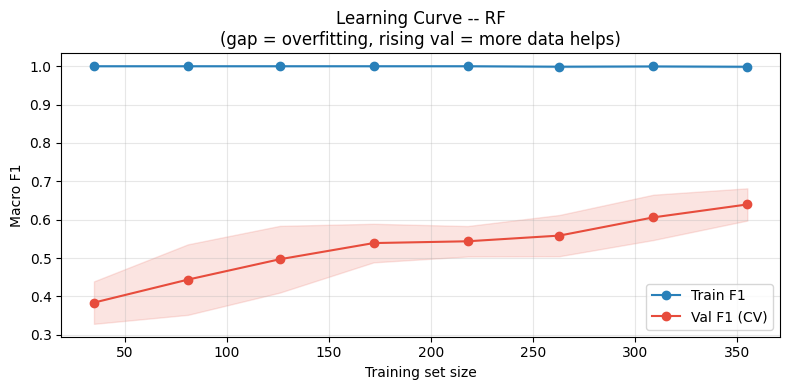

Final train F1 : 0.999
Final val F1   : 0.640
Gap            : 0.359
-> Large gap: overfitting -- needs more diverse subjects


In [10]:
# ── Learning Curve ─────────────────────────────────────────
# Shows whether more data would help — rising val curve = yes
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.pipeline import Pipeline

X_feat_all = np.array([extract_features(w) for w in X_train])

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(
        n_estimators=100, max_depth=10,
        min_samples_leaf=1, class_weight='balanced', random_state=42),
    X_feat_all, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_mean, 'o-', color='#2980B9', label='Train F1')
plt.fill_between(train_sizes, train_mean-train_std,
                 train_mean+train_std, alpha=0.15, color='#2980B9')
plt.plot(train_sizes, val_mean, 'o-', color='#E74C3C', label='Val F1 (CV)')
plt.fill_between(train_sizes, val_mean-val_std,
                 val_mean+val_std, alpha=0.15, color='#E74C3C')
plt.xlabel('Training set size')
plt.ylabel('Macro F1')
plt.title('Learning Curve -- RF\n(gap = overfitting, rising val = more data helps)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_rf.png', dpi=130)
plt.show()

final_gap = train_mean[-1] - val_mean[-1]
print(f'Final train F1 : {train_mean[-1]:.3f}')
print(f'Final val F1   : {val_mean[-1]:.3f}')
print(f'Gap            : {final_gap:.3f}')
if val_mean[-1] < val_mean[-2]:
    print('-> Val curve declining at end: overfitting')
elif final_gap > 0.15:
    print('-> Large gap: overfitting -- needs more diverse subjects')
elif val_mean[-1] < 0.5:
    print('-> Small gap but low val: underfitting -- needs more features or complexity')
else:
    print('-> Reasonable fit')